In [96]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.0 MB 11.2 MB/s eta 0:00:01
   -------------------- ------------------- 4.2/8.0 MB 11.6 MB/s eta 0:00:01
   ------------------------------- -------- 6.3/8.0 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 10.3 MB/s  0:00:00

   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -------------------------- 1/3 [joblib]
   ------------- -----------------

In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import kstest
from scipy.stats import chi2_contingency
from sklearn.impute import SimpleImputer

import warnings
warnings.filterwarnings('ignore')

In [48]:
data = pd.read_csv('../../assets/loan.csv')
data.shape

(614, 13)

In [49]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Creating New Features

In [50]:
data['Loan_Amount_Term'].value_counts() # data is in months

Loan_Amount_Term
360.0    512
180.0     44
480.0     15
300.0     13
84.0       4
240.0      4
120.0      3
60.0       2
36.0       2
12.0       1
Name: count, dtype: int64

In [51]:
data['Loan_Amount_Term'] = (data['Loan_Amount_Term'] / 12).astype(float)


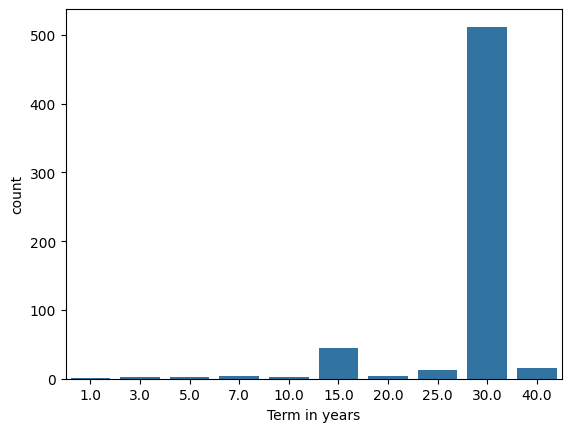

In [52]:
sns.countplot(x='Loan_Amount_Term', data=data)
plt.xlabel('Term in years')
plt.show()

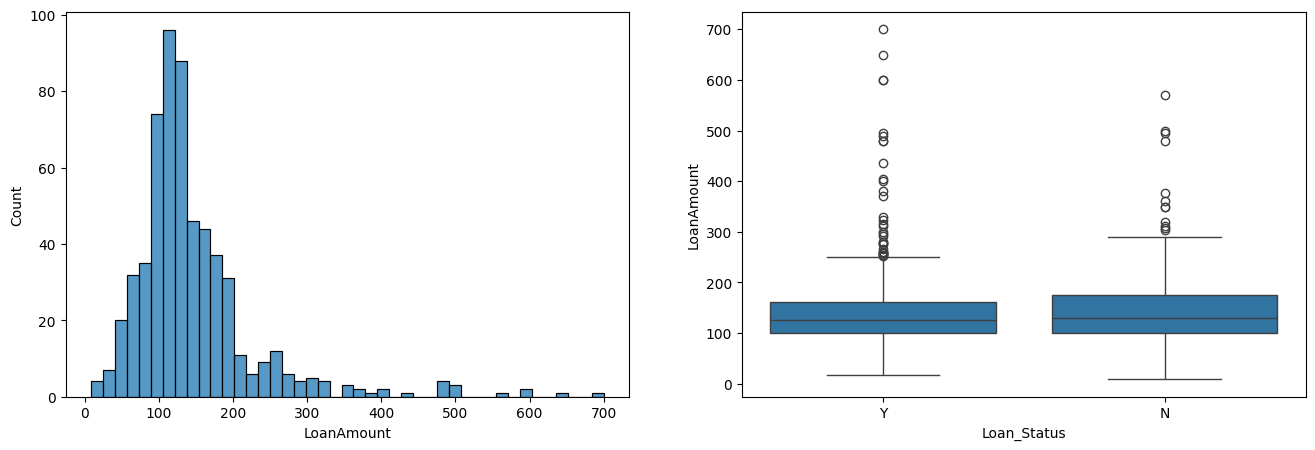

In [53]:
plt.figure(figsize=(16,5))
plt.subplot(121)
sns.histplot(data['LoanAmount'])

plt.subplot(122)
sns.boxplot(data=data,x='Loan_Status',y='LoanAmount')
plt.show()

In [54]:
data['Loan_Amount_per_year'] = data['LoanAmount']/data['Loan_Amount_Term']

In [55]:
data['EMI'] = data['Loan_Amount_per_year']*1000/12 # LoanAmount is in 1000s

In [56]:
data['TotalIncome'] = data['ApplicantIncome'] + data['CoapplicantIncome']
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Loan_Amount_per_year,EMI,TotalIncome
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,30.0,1.0,Urban,Y,NaN,NaN,5849.0
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,4.266667,355.555556,6091.0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,2.200000,183.333333,3000.0
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,4.000000,333.333333,4941.0
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,4.700000,391.666667,6000.0


In [58]:
data['TotalIncome_bin'] = pd.cut(data['TotalIncome'], bins=[0,2500,4000,6000,8000,10000,20000,40000,81000],
                               labels=['Low','Average','Medium','H1','H2','H3','H4','Very High'])
data['TotalIncome_bin'].value_counts()

TotalIncome_bin
Medium       224
Average      119
H1           115
H3            69
H2            45
Low           24
H4            13
Very High      5
Name: count, dtype: int64

In [59]:
data[['TotalIncome','EMI']]

,TotalIncome,EMI
0,5849.0,NaN
1,6091.0,355.555556
2,3000.0,183.333333
3,4941.0,333.333333
4,6000.0,391.666667
...,...,...
609,2900.0,197.222222
610,4106.0,222.222222
611,8312.0,702.777778
612,7583.0,519.444444


In [60]:
data['Able_to_pay_EMI'] = (data['TotalIncome']*0.3 > data['EMI']).astype(int)
data[['TotalIncome','EMI','Able_to_pay_EMI']]

,TotalIncome,EMI,Able_to_pay_EMI
0,5849.0,NaN,0
1,6091.0,355.555556,1
2,3000.0,183.333333,1
3,4941.0,333.333333,1
4,6000.0,391.666667,1
...,...,...,...
609,2900.0,197.222222,1
610,4106.0,222.222222,1
611,8312.0,702.777778,1
612,7583.0,519.444444,1


In [62]:
data['Able_to_pay_EMI'].value_counts()

Able_to_pay_EMI
1    574
0     40
Name: count, dtype: int64

In [64]:
vals = pd.crosstab(data['Able_to_pay_EMI'], data['Loan_Status'],normalize=True)
vals

Loan_Status,N,Y
Able_to_pay_EMI,,
0,0.030945,0.034202
1,0.281759,0.653094


H0: Loan Status and Able_to_Pay_EMI are not dependent
HA: Loan Status and Able_to_Pay_EMI are dependent

In [68]:
chi2_contingency(pd.crosstab(data['Able_to_pay_EMI'], data['Loan_Status']))

Chi2ContingencyResult(statistic=np.float64(4.467271867611989), pvalue=np.float64(0.03455011506195388), dof=1, expected_freq=array([[ 12.50814332,  27.49185668],
       [179.49185668, 394.50814332]]))

In [69]:
p_value = 0.03
alpha = 0.05

if p_value < alpha:
    print('Reject H0')
else:
    print('Fail to Reject H0')

Reject H0


Missing Values

In [72]:
(data.isnull().sum(), data.isna().sum())

(Loan_ID                  0
 Gender                  13
 Married                  3
 Dependents              15
 Education                0
 Self_Employed           32
 ApplicantIncome          0
 CoapplicantIncome        0
 LoanAmount              22
 Loan_Amount_Term        14
 Credit_History          50
 Property_Area            0
 Loan_Status              0
 Loan_Amount_per_year    36
 EMI                     36
 TotalIncome              0
 TotalIncome_bin          0
 Able_to_pay_EMI          0
 dtype: int64,
 Loan_ID                  0
 Gender                  13
 Married                  3
 Dependents              15
 Education                0
 Self_Employed           32
 ApplicantIncome          0
 CoapplicantIncome        0
 LoanAmount              22
 Loan_Amount_Term        14
 Credit_History          50
 Property_Area            0
 Loan_Status              0
 Loan_Amount_per_year    36
 EMI                     36
 TotalIncome              0
 TotalIncome_bin          0
 Able

In [76]:
missing_value = pd.DataFrame({'Missing Value':data.isnull().sum(),
                              'Percentage':(data.isnull().sum()/len(data))*100})
missing_value.sort_values(by='Missing Value', ascending=False)

,Missing Value,Percentage
Credit_History,50,8.143322
Loan_Amount_per_year,36,5.863192
EMI,36,5.863192
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Loan_ID,0,0.000000


In [78]:
data['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [80]:
data['Credit_History'].isnull().sum()

np.int64(50)

In [82]:
data['Credit_History'] = data['Credit_History'].fillna(2)
data['Credit_History'].value_counts()

Credit_History
1.0    475
0.0     89
2.0     50
Name: count, dtype: int64

There should not be any missing values

In [84]:
data['Credit_History'].isnull().sum()

np.int64(0)

In [86]:
data['Self_Employed'].value_counts()

Self_Employed
No     500
Yes     82
Name: count, dtype: int64

In [88]:
data['Self_Employed'].isnull().sum()

np.int64(32)

In [90]:
data['Self_Employed'] = data['Self_Employed'].fillna('Other')
data['Self_Employed'].value_counts()

Self_Employed
No       500
Yes       82
Other     32
Name: count, dtype: int64

# Simple Imputer:
# replacing missing values with library

In [102]:
list = [10,10,20,10,30,10, np.nan,50]
print('length of list:', len(list))
print('mean of list:', np.nanmean(list))

length of list: 8
mean of list: 20.0


In [104]:
imputer = SimpleImputer(strategy='mean')
df = pd.DataFrame(list)
imputer.fit_transform(df)

array([[10.],
       [10.],
       [20.],
       [10.],
       [30.],
       [10.],
       [20.],
       [50.]])

# Outlier treatemnt

In [106]:
data['TotalIncome_bin'] = data['TotalIncome_bin'].astype('object')

df_num = data.select_dtypes(include=np.number)
df_num.columns

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Loan_Amount_per_year', 'EMI',
       'TotalIncome', 'Able_to_pay_EMI'],
      dtype='object')

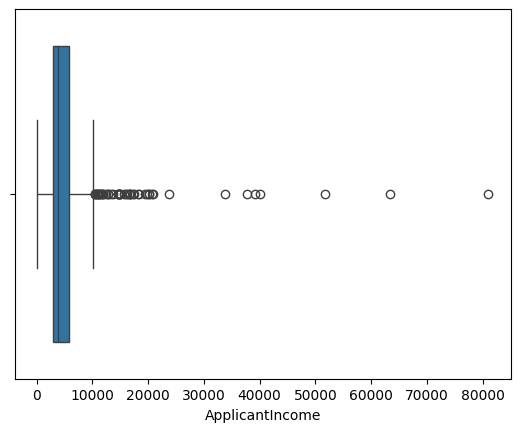

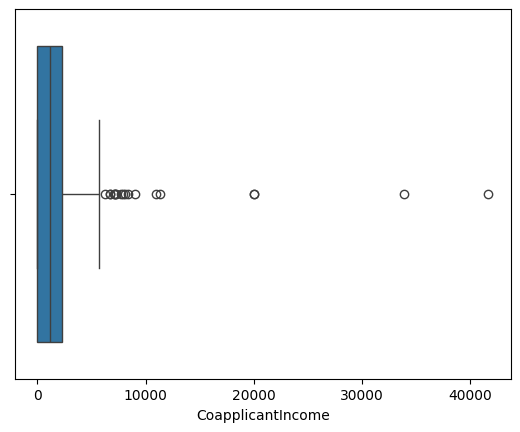

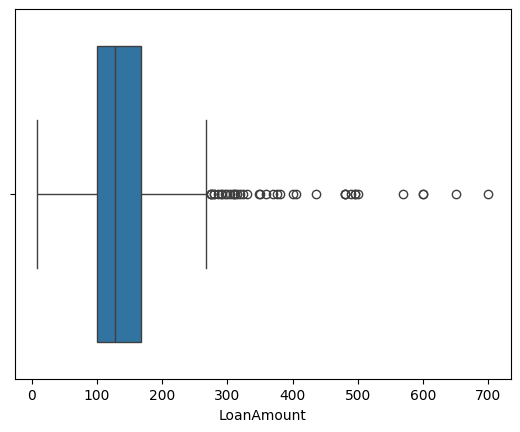

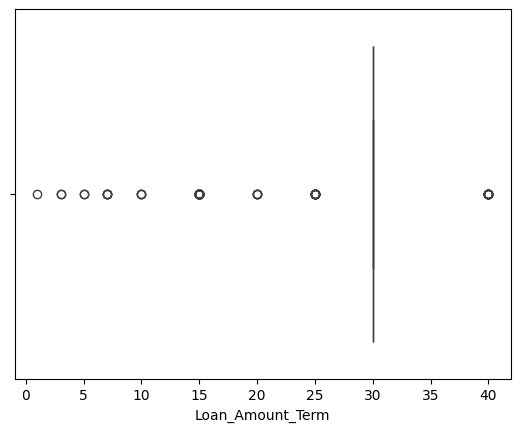

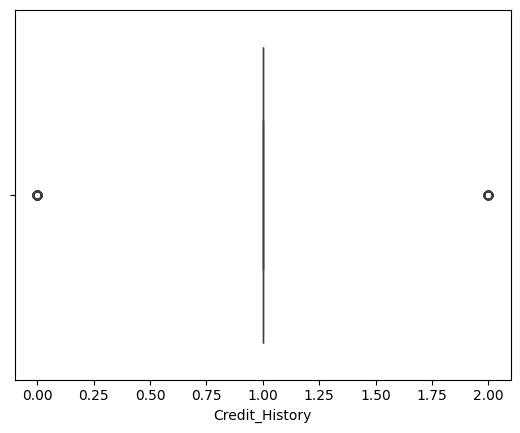

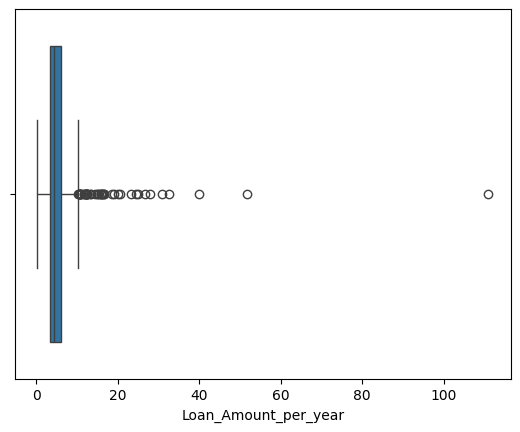

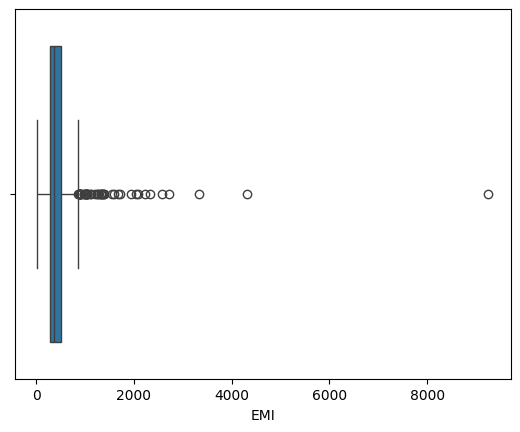

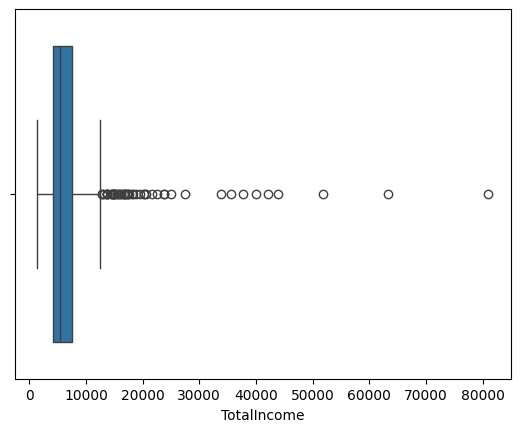

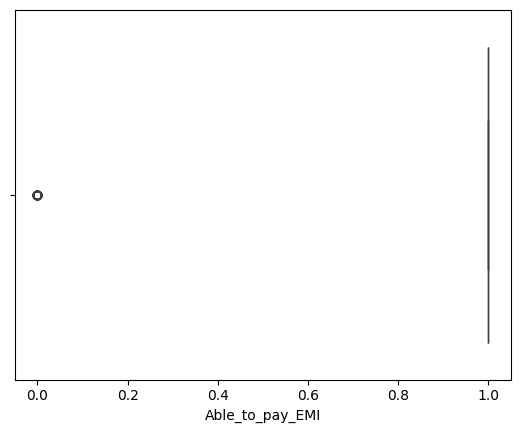

In [108]:
for col in enumerate(df_num):
    sns.boxplot(x=col[1],data=df_num)
    plt.show()

# how to remove Outliers?
# remove by using IQR

In [109]:
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1
print('IQR for numerical columns:', IQR)

IQR for numerical columns: ApplicantIncome         2917.500000
CoapplicantIncome       2297.250000
LoanAmount                68.000000
Loan_Amount_Term           0.000000
Credit_History             0.000000
Loan_Amount_per_year       2.733333
EMI                      227.777778
TotalIncome             3355.750000
Able_to_pay_EMI            0.000000
dtype: float64


In [112]:
dif_iqr = data[~((df_num < (Q1-1.5*IQR)) | (df_num > (Q3+1.5*IQR))).any(axis=1)]
print('shape of iqr filtered data:', dif_iqr.shape)
dif_iqr.head()

shape of iqr filtered data: (338, 18)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Loan_Amount_per_year,EMI,TotalIncome,TotalIncome_bin,Able_to_pay_EMI
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,30.0,1.0,Rural,N,4.266667,355.555556,6091.0,H1,1
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,30.0,1.0,Urban,Y,2.200000,183.333333,3000.0,Average,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,30.0,1.0,Urban,Y,4.000000,333.333333,4941.0,Medium,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,30.0,1.0,Urban,Y,4.700000,391.666667,6000.0,Medium,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,30.0,1.0,Urban,Y,8.900000,741.666667,9613.0,H2,1


In [116]:
quiz2 = np.array([15,18,22,23,25,28,40,75,200])
quiz2_Q1 = np.percentile(quiz2,25)
quiz2_Q3 = np.percentile(quiz2,75) 
quiz2_IQR = quiz2_Q3 - quiz2_Q1

print('Q1:', quiz2_Q1)
print('Q3:', quiz2_Q3)
print('IQR:', quiz2_IQR)

upper_bound = quiz2_Q3 + 1.5*quiz2_IQR
lower_bound = quiz2_Q1 - 1.5*quiz2_IQR
print('Upper Bound:', upper_bound)
print('Lower Bound:', lower_bound)

outliers = [x for x in quiz2 if x > upper_bound or x < lower_bound]
print('Outliers in the data:', outliers)

Q1: 22.0
Q3: 40.0
IQR: 18.0
Upper Bound: 67.0
Lower Bound: -5.0
Outliers in the data: [np.int64(75), np.int64(200)]


In [122]:
dt = np.array([0,1,2,3,4,5,10])
print('median: ',np.median(dt))

npq1 = np.percentile(dt,25)
npq3 = np.percentile(dt,75)
npiqr = npq3 - npq1
print('25th percentile:', npq1)
print('75th percentile:', npq3)
print('IQR:', npiqr)
print('Lower bound:', npq1 - 1.5*npiqr)
print('Upper bound:', npq3 + 1.5*npiqr)

median:  3.0
25th percentile: 1.5
75th percentile: 4.5
IQR: 3.0
Lower bound: -3.0
Upper bound: 9.0
